Для тюнинга гиперпараметров используется библиотека **Optuna** вместе с кроссвадидацией (StratifiedKFold).

## Импорт библиотек

In [2]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import numpy as np
import pandas as pd
import optuna

from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from category_encoders import OrdinalEncoder, CatBoostEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

from helper import divide_data, train_evaluate_models_cv
from plots import compare_metrics_heatmap

c:\Users\Kirill\Desktop\ML_Projects\ml-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# фиксируем состояние генератора псевдослучайных чисел.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Препроцессинг данных

In [5]:
NUMERICAL_FEATURES_LIST = ["tenure", "MonthlyCharges", "TotalCharges"]

CATEGORICAL_FEATURES_LIST = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

TARGET = "Churn"

In [6]:
CATEGORICAL_WITHOUT_SENIOR = [
    col for col in CATEGORICAL_FEATURES_LIST if col != "SeniorCitizen"
]

CATEGORICAL_ORDINAL_ENC = [
    col
    for col in CATEGORICAL_WITHOUT_SENIOR
    if col not in ["gender", "InternetService", "PaymentMethod"]
]

ordinal_mapping = [
    # {'col': 'gender', 'mapping': {'Female': 0, 'Male': 1}},
    {'col': 'Partner', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'Dependents', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'PhoneService', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'MultipleLines', 'mapping': {'No phone service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'OnlineSecurity', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'OnlineBackup', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'DeviceProtection', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'TechSupport', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'StreamingTV', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'StreamingMovies', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'Contract', 'mapping': {'Month-to-month': 0, 'One year': 1, 'Two year': 2}},
    {'col': 'PaperlessBilling', 'mapping': {'No': 0, 'Yes': 1}}
]

CATEGORICAL_CATBOOST_ENC = ["gender", "InternetService", "PaymentMethod"]

In [ ]:
preprocessor = ColumnTransformer(
    [
        # Числовые признаки: скалирование
        ("scaler_numerical", StandardScaler(), NUMERICAL_FEATURES_LIST),
        # Порядковые категориальные признаки
        (
            "ordinal_categorical",
            OrdinalEncoder(
                cols=CATEGORICAL_ORDINAL_ENC,
                mapping=ordinal_mapping,
                handle_unknown="value",
                handle_missing="value",
            ),
            CATEGORICAL_ORDINAL_ENC,
        ),
        # Категориальные признаки для CatBoost Encoding
        (
            "catboost_categorical",
            CatBoostEncoder(
                cols=CATEGORICAL_CATBOOST_ENC,
                sigma=None,
                a=1.0,
                handle_unknown="value",
                handle_missing="value",
                random_state=42,
            ),
            CATEGORICAL_CATBOOST_ENC,
        ),
    ],
    remainder="passthrough",  # колонки, не указанные в трансформерах, передаются без изменений
    verbose_feature_names_out=False,  # не добавлять префиксы к именам колонок
)

# Устанавливаем вывод в формате pandas DataFrame
preprocessor.set_output(transform="pandas")

,transformers,"[('scaler_numerical', ...), ('ordinal_categorical', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [8]:
base_model = (
    "model",
    CatBoostClassifier(
        random_state=SEED,
        verbose=0,
        task_type="CPU",
        allow_writing_files=False,
        auto_class_weights="Balanced",
    ),
)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [10]:
df = pd.read_csv("./Telecom_Customer_Churn.csv")

In [11]:
df_preprocessed = df.copy()
df_preprocessed = df_preprocessed.drop(columns=['customerID'])
df_preprocessed["TotalCharges"] = pd.to_numeric(df_preprocessed["TotalCharges"], errors="coerce")
df_preprocessed["TotalCharges"] = df_preprocessed["TotalCharges"].fillna(0)
df_preprocessed[TARGET] = np.where(df_preprocessed[TARGET] == 'Yes', 1, 0)

df_preprocessed["TotalChargesLog"] = np.log1p(df_preprocessed["TotalCharges"])
preprocessor.transformers[0][2].append("TotalChargesLog")

bins = [-np.inf, 12, 60, np.inf]
labels = [0, 1, 2]
df_preprocessed["tenure_bins"] = pd.cut(df_preprocessed["tenure"], bins=bins, labels=labels).astype(int)

In [12]:
X, y = divide_data(df_preprocessed, TARGET)

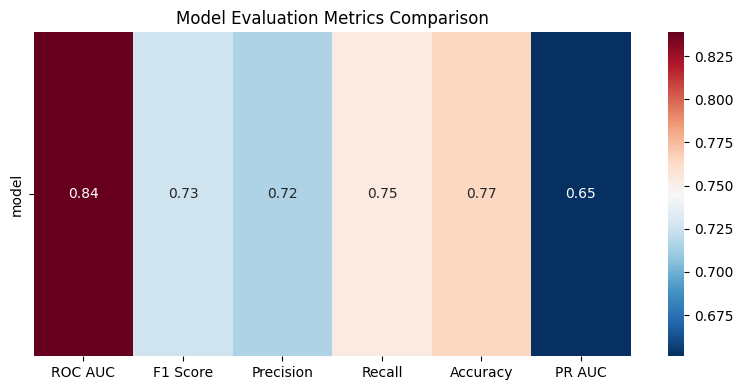

In [13]:
# Исходные метрики модели Catboost

initial_metrics = train_evaluate_models_cv(
    models=[base_model],
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

## 2. Подбор гиперпараметров

In [ ]:
def objective_pipeline(trial):
    params = {
        "iterations": trial.suggest_int(
            "iterations", 300, 1500
        ),  # количество деревьев (итераций бустинга); влияет на силу модели и риск переобучения.
        "depth": trial.suggest_int(
            "depth", 4, 10
        ),  # глубина деревьев; контролирует сложность модели.
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),  # скорость обучения; уменьшает шаг обновления весов, балансируя точность и обобщаемость.
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1e-3, 10.0, log=True
        ),  # коэффициент L2-регуляризации; уменьшает переобучение, штрафуя большие значения в листьях.
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),  # доля объектов, используемых для обучения каждого дерева; добавляет стохастичность.
        "rsm": trial.suggest_float(
            "rsm", 0.6, 1.0
        ),  # доля признаков, используемых при построении дерева; аналог feature bagging.
        "min_data_in_leaf": trial.suggest_int(
            "min_data_in_leaf", 1, 100
        ),  # минимальное количество объектов в листе; контролирует переобучение и размер листьев.
        "random_seed": SEED,
        "verbose": 0,
        "allow_writing_files": False,
        "task_type": "CPU",
        "auto_class_weights": "Balanced",
    }

    pipeline = Pipeline(
        steps=[("prep", preprocessor), ("model", CatBoostClassifier(**params))]
    )

    roc_aucs = []
    pr_aucs = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)

        y_pred = pipeline.predict_proba(X_val)[:, 1]
        roc_aucs.append(roc_auc_score(y_val, y_pred))
        pr_aucs.append(average_precision_score(y_val, y_pred))

    return np.mean(roc_aucs), np.mean(pr_aucs)


In [ ]:
# Запуск подбора гиперпараметров
study = optuna.create_study(
    directions=["maximize", "maximize"]
)
study.optimize(objective_pipeline, n_trials=100)


[I 2026-01-17 19:52:12,653] A new study created in memory with name: no-name-8f818963-8e5a-46c0-855e-9bf0bb9b8d23
[I 2026-01-17 19:53:25,925] Trial 0 finished with values: [0.8038977990437493, 0.5953906154617592] and parameters: {'iterations': 1213, 'depth': 9, 'learning_rate': 0.26370182270135833, 'l2_leaf_reg': 0.039422837108336065, 'subsample': 0.7033496894794802, 'rsm': 0.9679060679535147, 'min_data_in_leaf': 91}.
[I 2026-01-17 19:53:55,847] Trial 1 finished with values: [0.8278914297336719, 0.6318277632106545] and parameters: {'iterations': 1429, 'depth': 4, 'learning_rate': 0.062482205104796955, 'l2_leaf_reg': 5.070146757727582, 'subsample': 0.9062352464084407, 'rsm': 0.6595426332823539, 'min_data_in_leaf': 81}.
[I 2026-01-17 19:54:05,064] Trial 2 finished with values: [0.8362848766765106, 0.6499832819751479] and parameters: {'iterations': 343, 'depth': 6, 'learning_rate': 0.05445064457966694, 'l2_leaf_reg': 0.18308394094012134, 'subsample': 0.6780179044017769, 'rsm': 0.910114753

In [18]:
fig = optuna.visualization.plot_pareto_front(study)

fig.update_layout(
    xaxis_title="ROC-AUC",
    yaxis_title="PR-AUC"
)

fig.show()

In [30]:
optuna.visualization.plot_param_importances(study)

Самый важный гиперпараметр - learning_rate

In [35]:
best_trial = max(
    study.best_trials,
    key=lambda t: t.values[0]
)

best_params = best_trial.params

In [36]:
best_params

{'iterations': 411,
 'depth': 5,
 'learning_rate': 0.013592052269771294,
 'l2_leaf_reg': 0.009209162343261303,
 'subsample': 0.9786225873125499,
 'rsm': 0.6841315797710915,
 'min_data_in_leaf': 16}

In [ ]:
# Модель с подобранными гиперпараметрами

best_model = (
    "model",
    CatBoostClassifier(**best_params,
        random_state=SEED,
        verbose=0,
        task_type="CPU",
        allow_writing_files=False,
        auto_class_weights="Balanced",
    ),
)

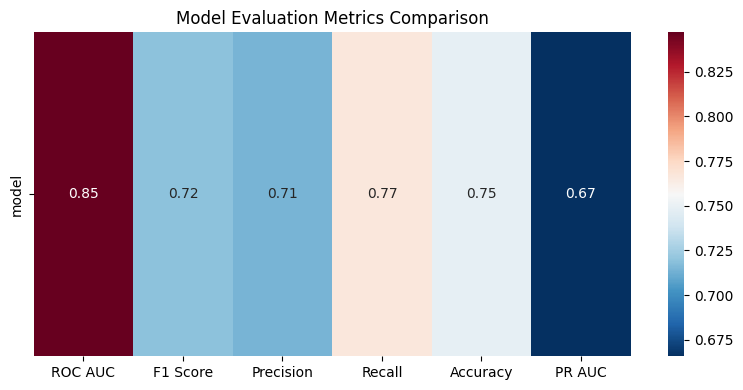

In [38]:
best_metrics = train_evaluate_models_cv(
    models=[best_model],
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
         ROC AUC  F1 Score  Precision    Recall  Accuracy    PR AUC
 model  0.983808  -0.88882  -0.177428  1.741607 -2.207746  2.236674)

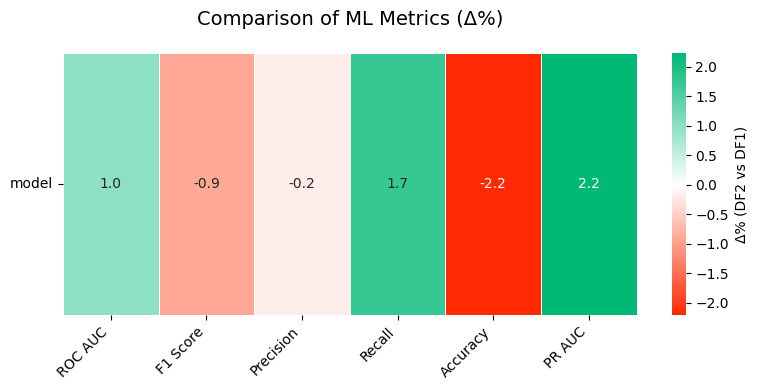

In [39]:
compare_metrics_heatmap(initial_metrics, best_metrics)

После подбора гиперпараметров **roc_auc** вырос на 1% и **pr_auc** вырос на 2.2%